uses environment `biopython`. 

In [36]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import os

In [22]:
total_reads=pd.read_csv("total_reads.tsv",sep="\t")
total_reads=total_reads.rename({"sum":"total_reads"},axis=1)
unique_reads=pd.read_csv("total_uniq_reads.tsv",sep="\t")
unique_reads["sum"]=unique_reads["sum"].str.split(" ").str[0]
unique_reads=unique_reads.rename({"sum":"unique_reads"},axis=1)
real_experimental_parameters=unique_reads.merge(total_reads,on="filename",how="inner",validate="one_to_one")
real_experimental_parameters["filename"]=real_experimental_parameters["filename"].str.removesuffix("_uniq.txt")

In [23]:
real_experimental_parameters

,filename,unique_reads,total_reads
0,SRR21787460_1,42317708,341856773
1,SRR21787460_2,184361905,341856773
2,SRR21787461_1,31101561,285499642
3,SRR21787461_2,141102814,285499642
4,SRR21787462_1,6612598,375550510
5,SRR21787462_2,34837369,375550510
6,SRR32774353_1,6331353,339016160
7,SRR32774353_2,31395271,339016160


In [33]:


def parse_hist_file(filename):
    """
    Parse a file with sections:
    ---FILE <name> ---
    ---LC_EXTRAP---
    <tsv data>
    ---BOUND_POP---
    <tsv data>

    Returns:
        dict with keys:
            'name' (str),
            'LC_EXTRAP' (pd.DataFrame),
            'BOUND_POP' (pd.DataFrame)
    """
    result = {"name": None, "LC_EXTRAP": None, "BOUND_POP": None}
    section = None
    buffers = {"LC_EXTRAP": StringIO(), "BOUND_POP": StringIO()}

    with open(filename) as f:
        for line in f:
            stripped = line.strip()
            if stripped.startswith("---FILE"):
                # Extract name
                parts = stripped.split()
                result["name"] = parts[1]
                result["name"]=result["name"].removesuffix("_uniq.hist")

                section = None
            elif stripped.startswith("---LC_EXTRAP---"):
                section = "LC_EXTRAP"
            elif stripped.startswith("---BOUND_POP---"):
                section = "BOUND_POP"
            elif stripped.startswith("---"):
                section = None
            else:
                if section in buffers:
                    buffers[section].write(line)

    # Convert buffers to DataFrames
    for key in ("LC_EXTRAP", "BOUND_POP"):
        buffers[key].seek(0)
        if buffers[key].getvalue().strip():
            result[key] = pd.read_csv(buffers[key], sep="\t")

    return result

def plot_expected_vs_reads(parsed, ax=None, save_path=None, show=False):
    """
    Plot EXPECTED_DISTINCT as a function of TOTAL_READS from the LC_EXTRAP table.
    Also plot the real experimental point from global DataFrame 'real_experimental_parameters'.

    Args:
        parsed (dict): Output from parse_hist_file(). Must contain key 'LC_EXTRAP' -> DataFrame
            with columns [TOTAL_READS, EXPECTED_DISTINCT, LOWER_0.95CI, UPPER_0.95CI].
        ax (matplotlib.axes.Axes, optional): Existing axes to draw on. If None, a new fig/ax is created.
        save_path (str, optional): If provided, saves the figure to this path.
        show (bool, optional): If True, calls plt.show().

    Returns:
        (fig, ax): The matplotlib Figure and Axes used for the plot.
    """
    df = parsed.get("LC_EXTRAP")
    if df is None or df.empty:
        raise ValueError("LC_EXTRAP is missing or empty.")

    required = ["TOTAL_READS", "EXPECTED_DISTINCT", "LOWER_0.95CI", "UPPER_0.95CI"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"LC_EXTRAP missing required columns: {missing}")

    # Ensure numeric dtype (in case TSV parsed them as strings)
    for col in required:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    # Main curve: expected distinct vs total reads
    ax.plot(df["TOTAL_READS"], df["EXPECTED_DISTINCT"], linestyle="-", linewidth=1.5, label="Expected")

    # 95% CI band (optional but helpful)
    ax.fill_between(
        df["TOTAL_READS"],
        df["LOWER_0.95CI"],
        df["UPPER_0.95CI"],
        alpha=0.2,
        linewidth=0,
    )

    # Try to plot real experimental point
    try:
        global real_experimental_parameters
        name = parsed.get("name")
        if name and 'filename' in real_experimental_parameters.columns:
            match = real_experimental_parameters.loc[
                real_experimental_parameters['filename'] == name
            ]
            if not match.empty:
                r = match.iloc[0]
                ax.scatter(
                    r['total_reads'], r['unique_reads'],
                    color='red', s=60, zorder=5, label='Experimental'
                )
    except Exception as e:
        print(f"Warning: could not plot experimental point: {e}")

    title = parsed.get("name") or "LC_EXTRAP"
    ax.set_title(f"{title}: Expected Distinct vs Total Reads")
    ax.set_xlabel("Total Reads")
    ax.set_ylabel("Expected Distinct")
    ax.margins(x=0)
    ax.legend()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show()

    return fig, ax


In [32]:
parse_hist_file("slurm-61713025_2.out")

{'name': 'SRR21787461_1',
 'LC_EXTRAP':       TOTAL_READS  EXPECTED_DISTINCT  LOWER_0.95CI  UPPER_0.95CI
 0    0.000000e+00                0.0           0.0           0.0
 1    1.000000e+07          2973310.5     2970498.2     2976104.8
 2    2.000000e+07          4378151.0     4373046.9     4382845.3
 3    3.000000e+07          5648607.0     5641299.5     5655528.3
 4    4.000000e+07          6863312.0     6853685.4     6872793.7
 ..            ...                ...           ...           ...
 995  9.950000e+09        405584680.2   381601057.4   491503615.1
 996  9.960000e+09        405815482.7   381796114.2   491907156.3
 997  9.970000e+09        406046212.4   381990994.7   492310630.0
 998  9.980000e+09        406276799.4   382185699.1   492714036.2
 999  9.990000e+09        406507208.8   382380227.6   493117375.1
 
 [1000 rows x 4 columns],
 'BOUND_POP':    median_estimated_unobs     lower_ci     upper_ci
 0             352274253.3  305862897.5  671367621.3}

ValueError: LC_EXTRAP is missing or empty.

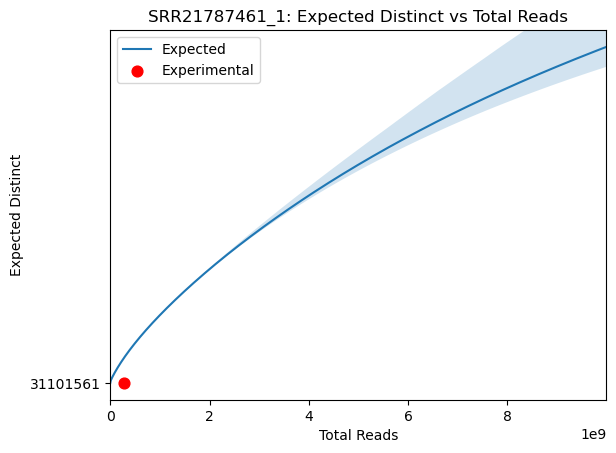

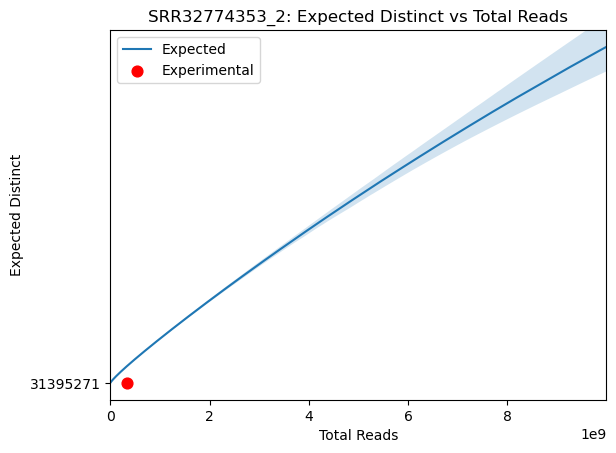

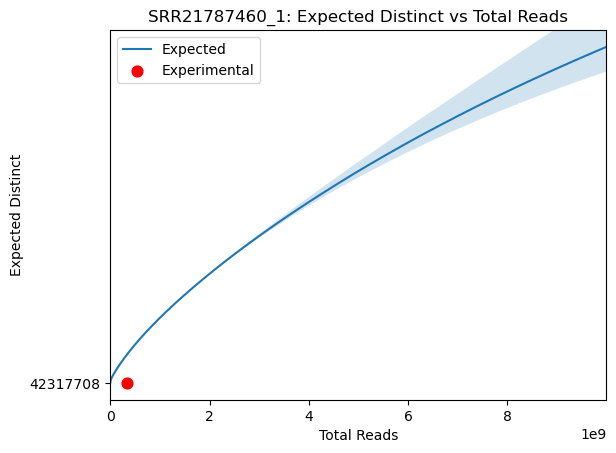

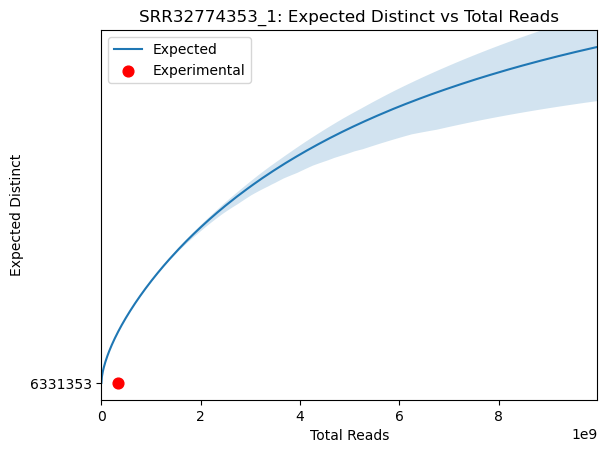

In [37]:
for fname in os.listdir('.'):
    if fname.startswith('slurm-') and os.path.isfile(fname):
        plot_expected_vs_reads(parse_hist_file(fname))